# SaveConfig Demo — Reproducible plots, data, and code

This notebook demonstrates the new save flow:
1. A `SaveConfig` controls *what* gets saved (figures, data, code, LaTeX) and *where*.
2. Every plot/analysis call accepts an optional `save=...` argument.
3. `record_script()` is a context manager that captures the source code of the with block.

Folder structure produced:
```
output/
├── figures/             # PNG, PDF, SVG, plus .tex snippets
└── scripts/             # .py files reproducing each figure
data/
└── processed/           # CSV data used in plots
```

In [ ]:
import sys, os
from pathlib import Path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import matplotlib.pyplot as plt

from src import (
    read_hdf5,
    list_readers,
    plot_transfer, plot_output,
    extract_vth_sqrt, extract_vth_linear, extract_ss, extract_on_off_ratio,
)
from src import SaveConfig, record_script, save_result

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('Registered readers:', list_readers())

Registered readers: ['keithley2600']


## 1. Build a SaveConfig

This object controls everything: where to write, which formats, what extras.

In [ ]:
SAVE = SaveConfig(
    enabled=True,                                # master switch
    output_dir=Path(PROJECT_ROOT) / 'output',    # base directory (project root)
    formats=['png', 'pdf'],                      # image formats
    save_data=True,                              # also save CSV
    save_code=True,                              # also save the script
    save_latex=True,                             # also save LaTeX snippet
    dpi=300,                                     # raster resolution
    overwrite=True,                              # overwrite existing files
)
print(SAVE)

SaveConfig(enabled=True, output_dir=PosixPath('/home/dibarra/Documents/egofets-project/output'), basename='', formats=['png', 'pdf'], save_data=True, save_code=True, save_latex=True, dpi=300, overwrite=True)


## 2. Load data using the new modular reader

In [ ]:
# reader name is now an explicit choice — autodetect also works
measurements = read_hdf5(
    os.path.join(PROJECT_ROOT, 'data/raw/2026-06-26_test1.hdf5'),
    reader='keithley2600',
)
print(f'Loaded {len(measurements)} measurements')
print('First transfer:', [k for k in measurements if measurements[k].mode == 'transfer'][0])

Loaded 39 measurements
First transfer: Batch1_Dispositivo1_Transfer1_00


## 3. Plot with save

Each call to `plot_transfer` / `plot_output` accepts a `save=` arg.

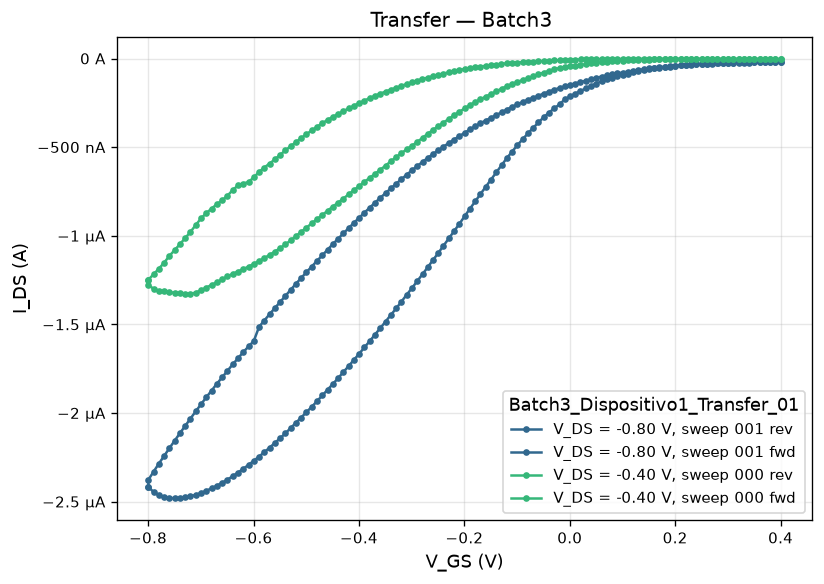

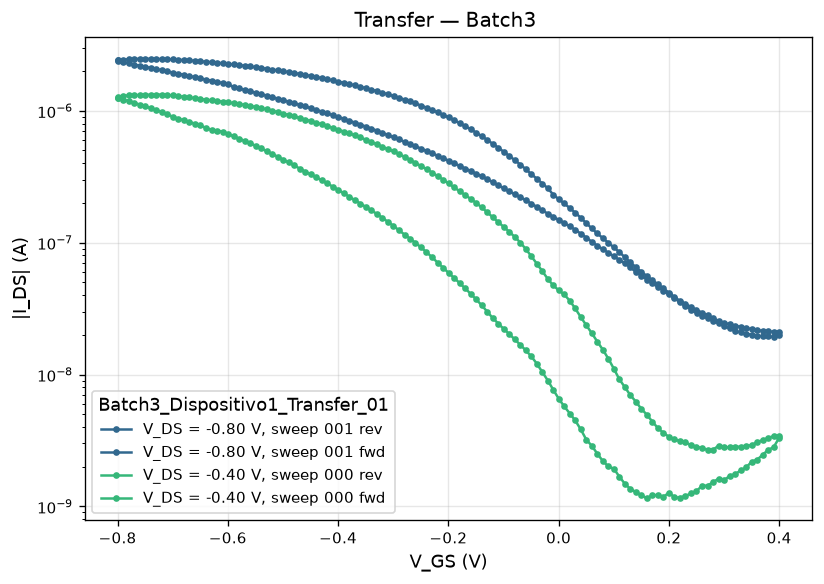

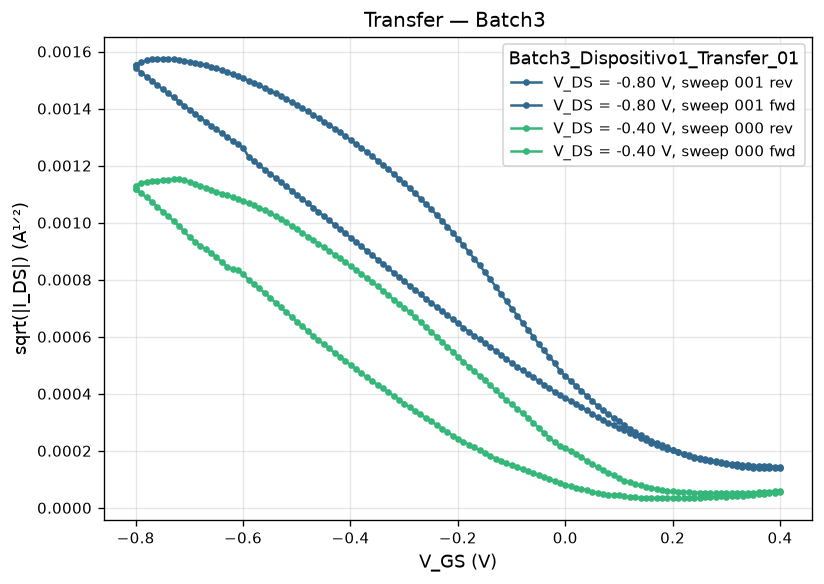

In [ ]:
m = measurements['Batch3_Dispositivo1_Transfer_01']

# Linear scale
fig, ax = plot_transfer(m, log=False, save=SAVE)

# Log scale (saves with auto-generated basename ending in '_log')
fig, ax = plot_transfer(m, log=True, save=SAVE)

# sqrt(Id) — for Vth extraction
fig, ax = plot_transfer(m, sqrt=True, save=SAVE)

## 4. Analysis with save

Each analysis function returns an `AnalysisResult` dataclass. Pass it to `save_result()` to persist everything (metrics JSON, fit CSV, optional figure).

In [ ]:
r_sqrt = extract_vth_sqrt(m, vds=-0.8, name=m.name)
print('Method:', r_sqrt.method)
print('Metrics:', r_sqrt.metrics)
print()
print('Dict-style access (backwards compatible):')
print(f'  r["Vth"] = {r_sqrt["Vth"]:.4f}')
print(f'  r["R²"] = {r_sqrt["R²"]:.4f}')
print(f'  r["V_DS"] = {r_sqrt["V_DS"]}')
print()
save_result(r_sqrt, save=SAVE)

Method: vth_sqrt
Metrics: {'Vth': np.float64(0.37199270434332704), 'slope': np.float64(-0.0013882778613823372), 'intercept': np.float64(0.0005164292360355861), 'R²': np.float64(0.9389316163720761), 'fit_points': 242}

Dict-style access (backwards compatible):
  r["Vth"] = 0.3720
  r["R²"] = 0.9389
  r["V_DS"] = -0.8



[PosixPath('/home/dibarra/Documents/egofets-project/data/processed/Batch3_Dispositivo1_Transfer_01_vth_sqrt_metrics.json'),
 PosixPath('/home/dibarra/Documents/egofets-project/data/processed/Batch3_Dispositivo1_Transfer_01_vth_sqrt_fit_data.csv')]

In [ ]:
r_lin = extract_vth_linear(m, vds=-0.4, name=m.name)
r_ss = extract_ss(m, vds=-0.4, name=m.name)
r_onoff = extract_on_off_ratio(m, vds=-0.8, name=m.name)

for r in (r_lin, r_ss, r_onoff):
    print(f'{r.method}: {r.metrics}')
    save_result(r, save=SAVE)

vth_linear: {'Vth': np.float64(0.13392730521780596), 'slope': np.float64(1.1095336056878134e-06), 'intercept': np.float64(-1.4859684585836454e-07), 'R²': np.float64(0.7648405753568243), 'fit_points': 242}
ss: {'SS': 0.05134184220241766, 'SS_mV_dec': 51.34184220241766, 'n_points': 241}
on_off: {'I_on': 2.4807e-06, 'I_off': 1.93715e-08, 'on_off_ratio': 128.05926231835429, 'log_on_off': 2.1074109957546576}


## 5. record_script — capture the code that produced the figure

Inside a `with record_script() as script:` block, all source lines of the caller's function (from the `with` line onwards) are captured. Pass them to `save_figure(..., code=...)` to also save a reproducible `.py` script.

Captured script lines:
      with record_script() as script:
          fig, ax = plot_transfer(m, log=True, sqrt=False, save=save)
      # script now contains the source lines of this with block
      # We could also pass it explicitly:
      # save_figure(fig, save, basename='explicit', code='\n'.join(script))
      return fig, ax, script


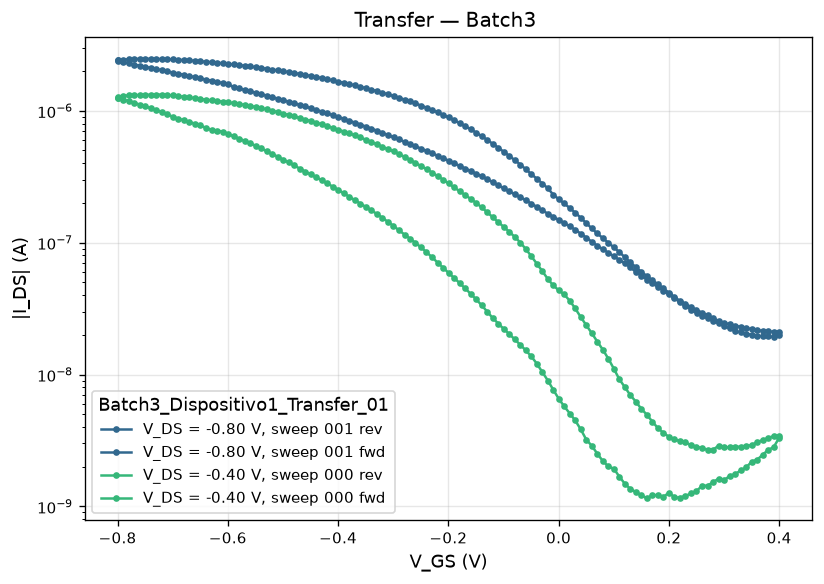

In [ ]:
def my_figure(m, save):
    """Reproducible figure: change values here to regenerate."""
    with record_script() as script:
        fig, ax = plot_transfer(m, log=True, sqrt=False, save=save)
    # script now contains the source lines of this with block
    # We could also pass it explicitly:
    # save_figure(fig, save, basename='explicit', code='\n'.join(script))
    return fig, ax, script

fig, ax, script = my_figure(m, SAVE)
print('Captured script lines:')
for line in script:
    print(f'  {line}')

## 6. Inspect what was saved

In [ ]:
for sub in ('figures', 'scripts'):
    d = Path('output') / sub
    if d.exists():
        print(f'--- {d} ---')
        for p in sorted(d.glob('*')):
            print(f'  {p.name}  ({p.stat().st_size} bytes)')

d = Path('data/processed')
if d.exists():
    print(f'--- {d} ---')
    for p in sorted(d.glob('*')):
        print(f'  {p.name}  ({p.stat().st_size} bytes)')

## 7. Toggle save off

Set `enabled=False` to skip saving entirely — useful when iterating without polluting the output folder.

Save enabled: False
Save enabled: True


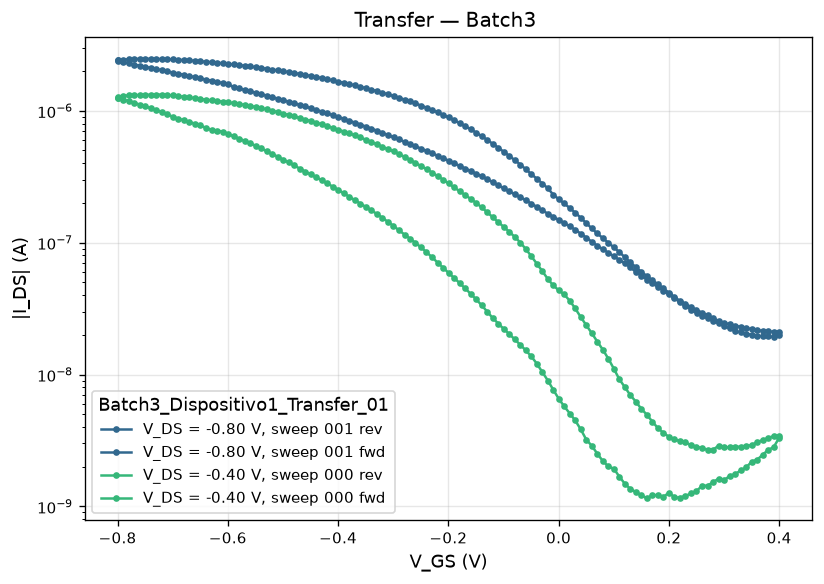

In [ ]:
SAVE.enabled = False
fig, ax = plot_transfer(m, log=True, save=SAVE)  # nothing saved
print('Save enabled:', SAVE.enabled)

# Re-enable for real saves
SAVE.enabled = True
print('Save enabled:', SAVE.enabled)

## 8. Custom basename

Override the auto-generated basename to make it more descriptive.

In [ ]:
from src.io import auto_basename
print('Auto basename example:', auto_basename({
    'name': 'Batch3_Disp1', 'plot': 'transfer', 'axis': 'log', 'vds': -0.8
}))

Auto basename example: Batch3_Disp1_transfer_log_vds-0.80
